In [ ]:
from google.colab import files
uploaded = files.upload()


Saving fault_25k_ngdr_20250224140917945.dbf to fault_25k_ngdr_20250224140917945.dbf
Saving fault_25k_ngdr_20250224140917945.prj to fault_25k_ngdr_20250224140917945.prj
Saving fault_25k_ngdr_20250224140917945.shp to fault_25k_ngdr_20250224140917945.shp
Saving fault_25k_ngdr_20250224140917945.shx to fault_25k_ngdr_20250224140917945.shx


In [ ]:
!pip install geopandas


In [ ]:
import geopandas as gpd

# Change filename to match your uploaded files
gdf = gpd.read_file("/content/fault_25k_ngdr_20250224140917945.shp")  # Don't include the other extensions


In [ ]:
gdf.head()

,gid,input_cent,edition_no,toposheet_,fault_type,fault_name,kinematics,strike,dip,displaceme,downthrow_,neotech_ac,age_activa,accession_,remarks,shape_leng,geometry
0,321,SR,1,57B07,Fault,None,None,None,None,None,None,None,None,None,Fault,1356.484344,"LINESTRING (76.48675 14.33825, 76.49038 14.339..."
1,324,SR,1,57C09,Fault,None,None,None,None,None,None,None,None,None,Fault,1357.476300,"LINESTRING (76.72403 13.887, 76.72631 13.88818..."
2,322,SR,1,57B08,Fault-Thrust,None,None,None,None,None,None,None,None,None,F,468.021139,"LINESTRING (76.31937 14.039, 76.32369 14.03914)"
3,414,SR,1,57E11,Fault,None,None,None,None,None,None,None,None,None,Local mesoscopic scale,296.081229,"LINESTRING (77.69063 15.29835, 77.69264 15.30018)"
4,415,SR,1,57E11,Fault,None,None,None,None,None,None,None,None,None,Local mesoscopic scale,330.632933,"LINESTRING (77.70419 15.27085, 77.70678 15.27245)"


In [ ]:
gdf.columns

Index(['gid', 'input_cent', 'edition_no', 'toposheet_', 'fault_type',
       'fault_name', 'kinematics', 'strike', 'dip', 'displaceme', 'downthrow_',
       'neotech_ac', 'age_activa', 'accession_', 'remarks', 'shape_leng',
       'geometry'],
      dtype='object')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   gid         16 non-null     int32   
 1   input_cent  16 non-null     object  
 2   edition_no  16 non-null     int32   
 3   toposheet_  16 non-null     object  
 4   fault_type  16 non-null     object  
 5   fault_name  0 non-null      object  
 6   kinematics  0 non-null      object  
 7   strike      0 non-null      object  
 8   dip         0 non-null      object  
 9   displaceme  0 non-null      object  
 10  downthrow_  0 non-null      object  
 11  neotech_ac  0 non-null      object  
 12  age_activa  0 non-null      object  
 13  accession_  0 non-null      object  
 14  remarks     8 non-null      object  
 15  shape_leng  16 non-null     float64 
 16  geometry    16 non-null     geometry
dtypes: float64(1), geometry(1), int32(2), object(13)
memory usage: 2.1+ KB


In [ ]:
gdf.shape


(16, 17)

In [ ]:
gdf.describe()

,gid,edition_no,shape_leng
count,16.000000,16.0,16.000000
mean,383.125000,1.0,1739.606185
std,49.393488,0.0,3972.019708
min,319.000000,1.0,145.539155
25%,322.750000,1.0,290.256588
50%,416.500000,1.0,330.360191
75%,421.250000,1.0,1356.732333
max,425.000000,1.0,16290.470162


In [ ]:
import geopandas as gpd

# Load the dataset
shapefile_path = "/content/fault_25k_ngdr_20250224140917945.shp"
gdf = gpd.read_file(shapefile_path)

# Check for missing values
missing_values = gdf.isnull().sum()
print("Missing Values:\n", missing_values)

# Check for duplicate rows
duplicate_count = gdf.duplicated().sum()
print("Number of Duplicates:", duplicate_count)


Missing Values:
 gid            0
input_cent     0
edition_no     0
toposheet_     0
fault_type     0
fault_name    16
kinematics    16
strike        16
dip           16
displaceme    16
downthrow_    16
neotech_ac    16
age_activa    16
accession_    16
remarks        8
shape_leng     0
geometry       0
dtype: int64
Number of Duplicates: 0


✅ Cleaned dataset saved as cleaned_dataset.csv


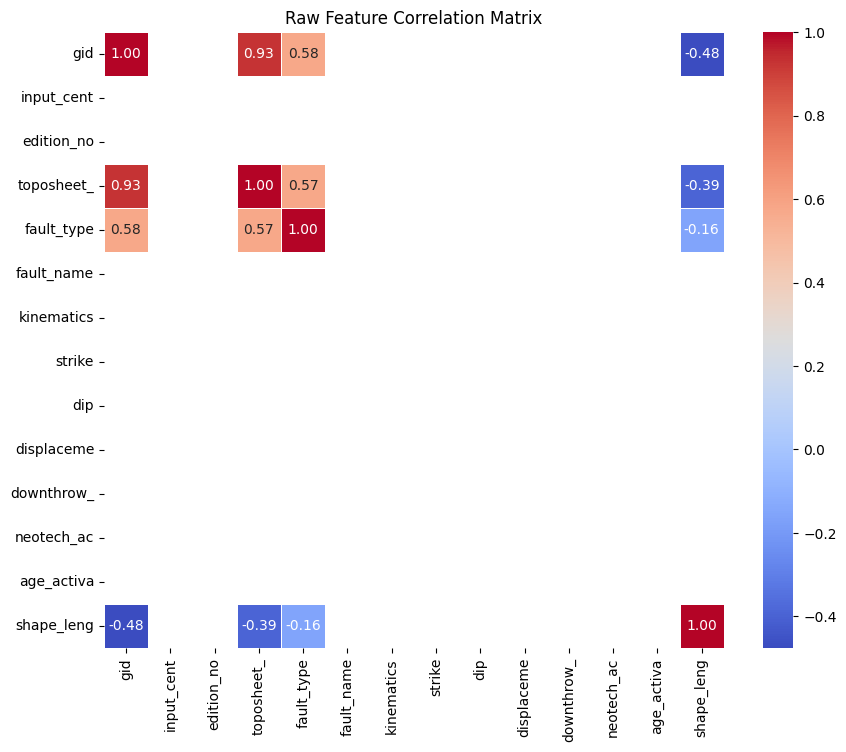

Random Forest Accuracy: -207.06%
XGBoost Accuracy: -396.44%
Gradient Boosting Accuracy: -398.42%

🏆 Best Model: Random Forest with Accuracy: -207.06%


In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Load the dataset
shapefile_path = "/content/fault_25k_ngdr_20250224140917945.shp"
gdf = gpd.read_file(shapefile_path)

# Drop geometry column if present
if "geometry" in gdf.columns:
    gdf = gdf.drop(columns=["geometry"])

# Handle missing values
gdf["kinematics"] = gdf["kinematics"].fillna("Unknown")
#gdf["trends"] = gdf["trends"].fillna(gdf["trends"].mode()[0])
gdf["accession_"] = gdf["accession_"].fillna("N/A")
gdf["remarks"] = gdf["remarks"].fillna("No Remarks")

# Drop unnecessary columns
gdf = gdf.drop(columns=["accession_", "remarks"], errors="ignore")

# Encode categorical variables
for col in gdf.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    gdf[col] = le.fit_transform(gdf[col])

# Save cleaned dataset
cleaned_csv_path = "cleaned_dataset.csv"
gdf.to_csv(cleaned_csv_path, index=False)
print(f"✅ Cleaned dataset saved as {cleaned_csv_path}")

# Correlation Matrix (raw)
correlation_matrix = gdf.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Raw Feature Correlation Matrix")
plt.show()

# Define target column
target_column = "shape_leng"
if target_column not in gdf.columns:
    target_column = gdf.columns[-1]  # fallback if shape_leng is missing

# Drop features with very low correlation to target
correlation_threshold = 0.05
low_corr_features = correlation_matrix[target_column].abs()[correlation_matrix[target_column].abs() < correlation_threshold].index.tolist()
gdf = gdf.drop(columns=low_corr_features, errors="ignore")

# Define features and target
X = gdf.drop(columns=[target_column])
y = gdf[target_column]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, objective="reg:squarederror", random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    accuracy = 100 * (1 - (rmse / np.mean(y_test)))
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.2f}%")

# Best model
best_model = max(results.items(), key=lambda x: x[1])
print(f"\n🏆 Best Model: {best_model[0]} with Accuracy: {best_model[1]:.2f}%")
